In [10]:
DATA_DIR="user_data/data/binance"
INTERVAL="5m"

In [11]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

from user_data.strategies.MlSignalStrategySimple import MlSignalStrategySimple

PAIR = "LINK/USDT"   # change this
SYMBOL = PAIR.replace("/", "").replace(":", "")

strategy = MlSignalStrategySimple(config={})
strategy.bot_start()

In [12]:
from pathlib import Path
import pandas as pd

raw_path = Path(DATA_DIR) / f"{PAIR.replace('/', '_')}-{INTERVAL}.parquet"
df = pd.read_parquet(raw_path).copy()

if "date" not in df.columns:
    df["date"] = pd.to_datetime(df["open_time"], utc=True)

df = df.sort_values("date").reset_index(drop=True)

df.tail()

,date,open,high,low,close,volume
83515,2026-03-17 23:35:00+00:00,9.82,9.83,9.81,9.81,3139.46
83516,2026-03-17 23:40:00+00:00,9.81,9.82,9.79,9.79,12068.76
83517,2026-03-17 23:45:00+00:00,9.80,9.82,9.79,9.81,17636.58
83518,2026-03-17 23:50:00+00:00,9.81,9.81,9.77,9.79,26623.03
83519,2026-03-17 23:55:00+00:00,9.79,9.80,9.78,9.79,8314.87


In [13]:
strategy.buy_threshold.value = 0.020
strategy.pred_hist_window.value = 5
strategy.pred_quantile.value = 0.65
strategy.min_imbalance.value = -0.01
strategy.max_range_pos.value = 0.92
strategy.min_rsi.value = 48.0
strategy.sell_threshold.value = 0.0

In [14]:
out = strategy.populate_indicators(df.copy(), {"pair": PAIR})
out["date"] = pd.to_datetime(df["date"])

# Filter from 10 Feb onwards
out = out[out["date"] >= "2026-02-10"]

debug = out[[
    "date",
    "close",
    "pred_proba",
    "pred",
    "threshold",
    "buy_signal"
]].copy()

debug.head(20)

,date,close,pred_proba,pred,threshold,buy_signal
73152,2026-02-10 00:00:00+00:00,8.84,0.482423,-0.017577,0.015428,False
73153,2026-02-10 00:05:00+00:00,8.83,0.486705,-0.013295,0.012326,False
73154,2026-02-10 00:10:00+00:00,8.85,0.468958,-0.031042,0.009757,False
73155,2026-02-10 00:15:00+00:00,8.84,0.477988,-0.022012,0.015864,False
73156,2026-02-10 00:20:00+00:00,8.82,0.483615,-0.016385,0.020238,False
73157,2026-02-10 00:25:00+00:00,8.83,0.485019,-0.014981,0.020238,False
73158,2026-02-10 00:30:00+00:00,8.84,0.475976,-0.024024,0.019762,False
73159,2026-02-10 00:35:00+00:00,8.83,0.476341,-0.023659,0.023220,False
73160,2026-02-10 00:40:00+00:00,8.81,0.480779,-0.019221,0.023000,False
73161,2026-02-10 00:45:00+00:00,8.81,0.478716,-0.021284,0.021884,False


In [15]:
latest = debug.iloc[-1]

print("Latest candle:")
print("date:", latest["date"])
print("price:", latest["close"])
print("pred_proba:", latest["pred_proba"])
print("pred:", latest["pred"])
print("threshold:", latest["threshold"])
print("pred > threshold:", latest["pred"] > latest["threshold"])
print("buy_signal:", latest["buy_signal"])

Latest candle:
date: 2026-03-17 23:55:00+00:00
price: 9.79
pred_proba: 0.4690784781773579
pred: -0.030921521822642073
threshold: 0.029895185786582977
pred > threshold: False
buy_signal: False


In [16]:
valid = debug.dropna()

ok = valid[
    (valid["pred"] > 0) &   # model slightly bullish
    (valid["pred"] >= valid["threshold"])
]

display(ok[["date", "pred", "threshold"]].tail(20))

print("Mean pred:", valid["pred"].mean())
print("Std pred:", valid["pred"].std())
print("Mean threshold:", valid["threshold"].mean())

print("Rate pred > threshold:", (valid["pred"] > valid["threshold"]).mean())
print("Total buy signals:", valid["buy_signal"].sum())

,date,pred,threshold
76926,2026-02-23 02:30:00+00:00,0.016381,0.013543
76927,2026-02-23 02:35:00+00:00,0.013789,0.013543
78652,2026-03-01 02:20:00+00:00,0.033160,0.016174
78654,2026-03-01 02:30:00+00:00,0.019051,0.016174
78655,2026-03-01 02:35:00+00:00,0.026300,0.018727
78873,2026-03-01 20:45:00+00:00,0.010872,0.005426
78874,2026-03-01 20:50:00+00:00,0.013947,0.005426
78875,2026-03-01 20:55:00+00:00,0.011860,0.008726
80309,2026-03-06 20:25:00+00:00,0.018730,0.015256
80320,2026-03-06 21:20:00+00:00,0.015053,0.004062


Mean pred: -0.038495209556713324
Std pred: 0.016923125485229715
Mean threshold: 0.04137313958453939
Rate pred > threshold: 0.0013503086419753086
Total buy signals: 3


In [17]:
almost = valid[
    (valid["pred"] > 0) &   # model slightly bullish
    (valid["pred"] <= valid["threshold"])
]

almost[["date", "pred", "threshold"]].tail(20)

,date,pred,threshold
80621,2026-03-07 22:25:00+00:00,0.015157,0.031971
80685,2026-03-08 03:45:00+00:00,0.002878,0.025937
80736,2026-03-08 08:00:00+00:00,0.011759,0.038746
80774,2026-03-08 11:10:00+00:00,0.002065,0.049749
80782,2026-03-08 11:50:00+00:00,0.009304,0.009820
80813,2026-03-08 14:25:00+00:00,0.000937,0.019357
80814,2026-03-08 14:30:00+00:00,0.006138,0.014935
80841,2026-03-08 16:45:00+00:00,0.001861,0.012320
80843,2026-03-08 16:55:00+00:00,0.002202,0.006219
80909,2026-03-08 22:25:00+00:00,0.013810,0.015508


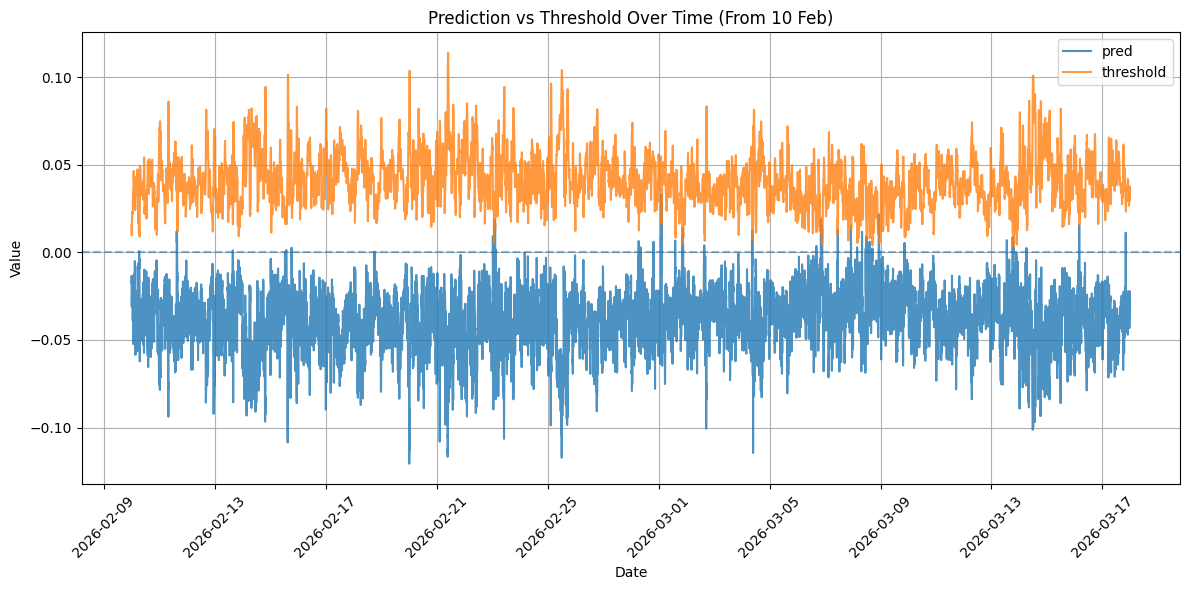

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# Sort by time
debug = debug.sort_values("date")

plt.figure(figsize=(12, 6))

plt.plot(debug["date"], debug["pred"], label="pred", alpha=0.8)
plt.plot(debug["date"], debug["threshold"], label="threshold", alpha=0.8)

plt.axhline(0, linestyle="--", alpha=0.5)

plt.title("Prediction vs Threshold Over Time (From 10 Feb)")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()